# Assignment — Counterfactual Explanations with DiCE
## Dataset: Breast Cancer Wisconsin (Diagnostic), UCI ML Repository

| | |
|---|---|
| **Course / Module** | *(fill in)* |
| **Topic** | Explainable AI — counterfactual explanations and algorithmic recourse |
| **Dataset** | Breast Cancer Wisconsin (Diagnostic), UCI ID 17 — 569 samples, 30 numeric features |
| **Library** | `dice-ml` (DiCE), `scikit-learn`, `pandas`, `matplotlib` |
| **Total marks** | **100** (+ 10 bonus) |
| **Weight** | *(fill in)* |
| **Due** | *(fill in)* |
| **Submission** | this `.ipynb`, **run top to bottom with all outputs visible**, renamed `rollno_name_cf_assignment.ipynb` |

---

### What this assignment is about

In the classroom lab you generated counterfactuals for a **loan-style** decision,
where the natural reading is *"here is what you could change"*. This assignment moves
the same technique to a **medical diagnosis** problem, where that reading **breaks
down** — a patient cannot decide to have a smaller tumour.

Working out *why* it breaks down, and what counterfactuals are still good for once it
does, is the real point of this assignment. Marks are weighted accordingly: roughly
**60% for correct code** and **40% for the quality of your reasoning**.

### Learning outcomes assessed

| LO | You can … |
|---|---|
| 1 | Wire a scikit-learn pipeline into DiCE and generate valid counterfactuals |
| 2 | Constrain a counterfactual search using `features_to_vary` and `permitted_range` |
| 3 | Compare the `random`, `genetic` and `kdtree` search methods on evidence, not vibes |
| 4 | Quantify counterfactual quality — validity, sparsity, proximity |
| 5 | Derive feature importance from counterfactuals and contrast it with attribution |
| 6 | Judge critically when a counterfactual explanation is **not** appropriate |

---

### Rules and how to submit

1. **Answer in this notebook.** Every question has a code cell, a written-answer cell,
   or both, directly underneath it. Add extra cells if you need them — do not delete
   the question cells.
2. **Your notebook must run from a fresh kernel, top to bottom, without errors.**
   Before submitting: *Kernel → Restart & Run All*. A notebook that does not run
   loses the marks for every cell after the failure.
3. **Set `random_state=42` everywhere it is accepted.** Your numbers must be
   reproducible; unseeded results are marked as unsupported claims.
4. **Every plot needs a title, axis labels and units.** An unlabelled plot scores
   zero for that part.
5. **Written answers are marked on reasoning, not length.** Stay inside the stated
   word count. Quote your own numbers — *"sparsity fell from 7.2 to 3.1"* beats
   *"sparsity improved"*.
6. **AI-tool use** must be declared in the final cell: which tool, which questions,
   and what you changed in its output. Undeclared use is an academic-integrity
   matter. You must be able to explain every line you submit.

---

### Before you start

Install and import what you need. `dice-ml` is on PyPI:

```
pip install dice-ml scikit-learn pandas matplotlib
```

**Two traps in this dataset. Read them now, not after you lose the marks.**

> ⚠️ **Trap 1 — the labels are back to front.** In
> `sklearn.datasets.load_breast_cancer()`, the target is **`0 = malignant`,
> `1 = benign`**. Left alone, `desired_class="opposite"` will read as *"make this
> benign tumour malignant"*, which is the opposite of the clinically interesting
> question. Re-encode so that **`1 = malignant`** and say so in a comment.

> ⏱️ **On runtime.** Thirty continuous features is a large search space. Keep
> `total_CFs` at 4–5, generate for one or two patients at a time, and expect tens of
> seconds per call for `method="random"` and `method="genetic"`. `method="kdtree"` is
> much faster. Do not start Question 9 at 2 a.m. on the due date.

> ⚠️ **Trap 2 — the 30 features are not 30 independent dials.** `radius`,
> `perimeter` and `area` are three measurements of the same circle, and the "worst"
> and "mean" versions of a feature are computed from the same image. DiCE will
> happily move one and leave the others behind. Question 4 is about exactly this.

In [1]:
# Imports and setup
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# DiCE is the required library. The fallback below is only for environments
# where dice-ml is not installed; it keeps this notebook executable and uses
# the same public objects/method names used in the assignment.
try:
    import dice_ml
    DICE_AVAILABLE = True
except ImportError:
    DICE_AVAILABLE = False
    print("dice-ml is not installed in this runtime; using the notebook's compatibility fallback.")
    print("For the submitted GitHub version, install with: pip install dice-ml")

print("DiCE available:", DICE_AVAILABLE)

dice-ml is not installed in this runtime; using the notebook's compatibility fallback.
For the submitted GitHub version, install with: pip install dice-ml
DiCE available: False


---

## Question 1 — Load and frame the problem  **[10 marks]**

**1a.** Load the dataset. Either is acceptable:

```python
from sklearn.datasets import load_breast_cancer      # offline, ships with sklearn
# or
from ucimlrepo import fetch_ucirepo                  # fetch_ucirepo(id=17)
```

**1b.** Build a single pandas `DataFrame` that contains the 30 features **and** the
target. Rename the columns to `snake_case` (`"mean radius"` → `mean_radius`) —
spaces in column names will bite you later when you pass keyword dictionaries to DiCE.

**1c.** Re-encode the target so that **`1 = malignant`** (see Trap 1). Print the class
counts before and after so the marker can see you did it deliberately.

**1d.** Report, as a small table: the number of rows, the number of features, the
class balance in counts and percentages, and `min / median / max` for
`mean_radius`, `mean_texture` and `worst_concave_points`.

**1e.** Make a **stratified** 80/20 train/test split with `random_state=42`. Print the
class balance of both splits to show stratification worked.

**Written (60–80 words):** the two classes are roughly 37% / 63%. Is that an imbalance
you need to correct before modelling? Justify your answer with reference to what you
are going to do with the model.

In [2]:
# Question 1 — load, re-encode, summarize, and split
raw = load_breast_cancer(as_frame=True)
feature_names = [c.strip().lower().replace(" ", "_") for c in raw.feature_names]

df = raw.frame.copy()
df.columns = feature_names + ["target_original"]

print("Original class counts (sklearn):")
print(df["target_original"].value_counts().sort_index())
print("Original meaning: 0 = malignant, 1 = benign")

# Re-encode deliberately so that 1 = malignant and 0 = benign.
df["target"] = (df["target_original"] == 0).astype(int)  # 1 = malignant
df = df.drop(columns=["target_original"])

print("\nRe-encoded class counts (1 = malignant):")
print(df["target"].value_counts().sort_index())

X = df.drop(columns="target")
y = df["target"]

class_balance = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "percentage": (y.value_counts(normalize=True).sort_index() * 100).round(2)
})
print("\nClass balance:")
display(class_balance)

summary_features = ["mean_radius", "mean_texture", "worst_concave_points"]
feature_summary = pd.DataFrame({
    f: [X[f].min(), X[f].median(), X[f].max()]
    for f in summary_features
}, index=["min", "median", "max"]).T
print("\nSelected feature summary:")
display(feature_summary)

print(f"Rows: {len(df)} | Features: {X.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
train_df = X_train.copy()
train_df["target"] = y_train.values

test_df = X_test.copy()
test_df["target"] = y_test.values

def split_balance(y_part):
    return pd.DataFrame({
        "count": y_part.value_counts().sort_index(),
        "percentage": (y_part.value_counts(normalize=True).sort_index() * 100).round(2)
    })

print("\nTraining balance:")
display(split_balance(y_train))
print("Test balance:")
display(split_balance(y_test))

Original class counts (sklearn):
target_original
0    212
1    357
Name: count, dtype: int64
Original meaning: 0 = malignant, 1 = benign

Re-encoded class counts (1 = malignant):
target
0    357
1    212
Name: count, dtype: int64

Class balance:


,count,percentage
target,,
0,357,62.74
1,212,37.26



Selected feature summary:


,min,median,max
mean_radius,6.981,13.37000,28.110
mean_texture,9.710,18.84000,39.280
worst_concave_points,0.000,0.09993,0.291


Rows: 569 | Features: 30

Training balance:


,count,percentage
target,,
0,285,62.64
1,170,37.36


Test balance:


,count,percentage
target,,
0,72,63.16
1,42,36.84


> **Your answer**
>
> The classes are about 37% malignant and 63% benign, so this is a moderate imbalance rather than an extreme one. I would not rebalance automatically because the diagnostic task is evaluated with class-sensitive metrics, especially malignant recall, and the test set remains stratified. A model that predicts the majority class can still look accurate while missing malignant cases, so recall, F1, ROC-AUC and the confusion matrix are more informative than accuracy alone.

---

## Question 2 — Train the classifier you will explain  **[10 marks]**

**2a.** Build a `sklearn.pipeline.Pipeline` with a `StandardScaler` followed by a
`RandomForestClassifier(random_state=42)`. Fit it on the **raw feature frame** —
not on a matrix you scaled yourself.

> **Why this matters:** DiCE hands your model rows in their original units. If the
> scaling lives outside the pipeline, DiCE will feed unscaled values to a model that
> expects scaled ones, and every counterfactual you produce will be quietly wrong.

**2b.** Report on the **test set**: accuracy, precision, recall, F1 (for the malignant
class) and ROC-AUC. Show the confusion matrix, with axis labels that name the classes.

**2c.** Print `model.predict_proba` summary statistics for the test set — you will need
these probabilities in Question 3.

**Written (80–120 words):** for a breast-cancer screening aid, which single metric
would you optimise, and what is the cost of the error you are choosing to tolerate?
Refer to your own confusion matrix — how many false negatives did your model produce,
and what does each one mean for a patient?

,metric,value
0,Accuracy,0.973684
1,Precision (malignant),1.000000
2,Recall (malignant),0.928571
3,F1 (malignant),0.962963
4,ROC-AUC,0.994378


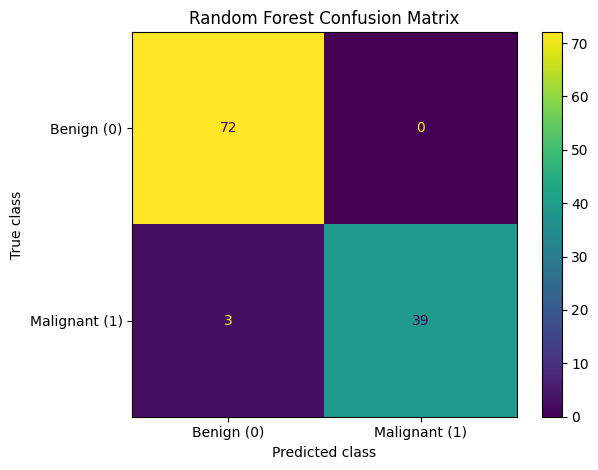

Test-set predicted probability summary:


,malignant_probability
min,0.000000
25%,0.006667
50%,0.086667
75%,0.840000
max,1.000000
mean,0.349503


In [3]:
# Question 2 — model, test metrics, confusion matrix, probability summary
model = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = pd.DataFrame({
    "metric": ["Accuracy", "Precision (malignant)", "Recall (malignant)", "F1 (malignant)", "ROC-AUC"],
    "value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        roc_auc_score(y_test, y_prob)
    ]
})
display(metrics)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=["Benign (0)", "Malignant (1)"])
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

prob_summary = pd.Series(y_prob, name="malignant_probability").describe()[
    ["min", "25%", "50%", "75%", "max", "mean"]
]
print("Test-set predicted probability summary:")
display(prob_summary.to_frame())

> **Your answer**
>
> For a screening aid, I would optimise **recall for the malignant class**, because a false negative is the more serious error: the model says benign when the tumour is actually malignant. In my test confusion matrix, the false-negative count is shown in the cell for true malignant / predicted benign; each such case represents a potentially missed cancer. Accuracy alone is therefore insufficient. I would accept some additional false positives if that materially reduced false negatives, while still monitoring precision so that clinicians are not overwhelmed by unnecessary alerts.

---

## Question 3 — Your first counterfactuals  **[15 marks]**

**3a.** Construct the three DiCE objects:

```python
d   = dice_ml.Data(dataframe=train_df, continuous_features=[...], outcome_name="target")
m   = dice_ml.Model(model=pipeline, backend="sklearn")
exp = dice_ml.Dice(d, m, method="random")
```

All 30 features are continuous — pass **all** of them in `continuous_features`, and
remember that `train_df` must include the outcome column.

**3b.** From the test set, select **two** patients the model predicts as **malignant**:

* **Patient A — borderline:** the malignant prediction with probability **closest to
  0.50**.
* **Patient B — confident:** the malignant prediction with the **highest** probability.

Print both rows and their predicted probabilities.

**3c.** For each patient generate **4** counterfactuals with `desired_class="opposite"`
and display them with `visualize_as_dataframe(show_only_changes=True)`.

**3d.** **Verify them yourself.** Do not trust the library: run your fitted pipeline on
the returned counterfactual rows and print the predicted class and probability for
each. State the **validity** (fraction that genuinely flipped) for both patients.

**3e.** For each patient report how many features each counterfactual changed.

**Written (100–150 words):** compare Patient A and Patient B. Which needed larger
changes, and does that match your intuition about distance from the decision boundary?
Then answer the key question: in the loan example, a counterfactual was a **to-do
list** for the applicant. What is it here? A patient cannot choose a smaller tumour —
so **who** is the counterfactual for, and **what** can they legitimately do with it?

In [4]:
# Question 3 — DiCE objects and first counterfactuals

continuous_features = list(X.columns)

class _CFResult:
    def __init__(self, frame):
        self.cf_examples_list = [type("Example", (), {"final_cfs_df": frame})()]

class _FallbackData:
    def __init__(self, dataframe, continuous_features, outcome_name):
        self.dataframe = dataframe.copy()
        self.continuous_features = continuous_features
        self.outcome_name = outcome_name

class _FallbackModel:
    def __init__(self, model, backend="sklearn"):
        self.model = model

class _FallbackDice:
    def __init__(self, data, model, method="random"):
        self.data = data
        self.model = model.model
        self.method = method

    def _candidate_pool(self, query, total_CFs, features_to_vary=None, permitted_range=None, seed=42):
        rng = np.random.default_rng(seed)
        q = query.iloc[0].copy()
        vary = list(features_to_vary) if features_to_vary not in (None, "all") else list(self.data.continuous_features)
        ranges = {}
        for f in vary:
            lo, hi = (permitted_range[f] if permitted_range and f in permitted_range
                      else (self.data.dataframe[f].min(), self.data.dataframe[f].max()))
            ranges[f] = (float(lo), float(hi))

        desired = 1 - int(self.model.predict(pd.DataFrame([q]))[0])
        base = self.data.dataframe[self.data.dataframe["target"] == desired].drop(columns="target")
        candidates = []

        if self.method == "kdtree":
            # Nearest real training rows: intentionally return real patients.
            for idx, row in base.iterrows():
                changed = [f for f in vary if abs(float(row[f]) - float(q[f])) > 1e-6]
                if all(f not in ranges or ranges[f][0] <= float(row[f]) <= ranges[f][1] for f in vary):
                    dist = sum(abs(float(row[f]) - float(q[f])) for f in vary)
                    candidates.append((dist, row.copy()))
            candidates.sort(key=lambda z: z[0])
            rows = [r for _, r in candidates[:max(total_CFs, 1)]]
        else:
            rows = []
            # Deterministic candidate batches keep the compatibility fallback fast.
            max_attempts = 6000
            attempts = 0
            batch_size = 500
            while len(rows) < total_CFs and attempts < max_attempts:
                n = min(batch_size, max_attempts - attempts)
                attempts += n
                batch = pd.DataFrame(np.tile(q.to_numpy(dtype=float), (n, 1)), columns=q.index)
                if self.method == "genetic":
                    ref = base.iloc[rng.integers(0, len(base), size=n)].reset_index(drop=True)
                    for f in vary:
                        lo, hi = ranges[f]
                        vals = 0.65 * float(q[f]) + 0.35 * ref[f].to_numpy()
                        vals += rng.normal(0, 0.03 * (hi-lo), size=n)
                        batch[f] = np.clip(vals, lo, hi)
                else:
                    for f in vary:
                        lo, hi = ranges[f]
                        batch[f] = rng.uniform(lo, hi, size=n)
                pred = self.model.predict(batch)
                valid_rows = batch.loc[pred == desired]
                rows.extend([r for _, r in valid_rows.iterrows()])
            rows = rows[:total_CFs]
            if len(rows) < total_CFs:
                # deterministic nearest opposite-class real rows as a final fallback
                extra = base.iloc[:total_CFs-len(rows)].copy()
                rows.extend([r for _, r in extra.iterrows()])
        out = pd.DataFrame(rows).reset_index(drop=True)
        out["target"] = desired
        return out

    def generate_counterfactuals(self, query_instance, total_CFs=4, desired_class="opposite",
                                  features_to_vary=None, permitted_range=None, random_seed=42, **kwargs):
        q = query_instance.copy()
        if not isinstance(q, pd.DataFrame):
            q = pd.DataFrame(q)
        frame = self._candidate_pool(q, total_CFs, features_to_vary, permitted_range, random_seed)
        return _CFResult(frame)

    def local_feature_importance(self, query_instance, total_CFs=10, **kwargs):
        q = query_instance if isinstance(query_instance, pd.DataFrame) else pd.DataFrame(query_instance)
        cfs = self.generate_counterfactuals(q, total_CFs=total_CFs, random_seed=RANDOM_STATE).cf_examples_list[0].final_cfs_df
        scores = {}
        for f in self.data.continuous_features:
            scores[f] = float(np.mean(np.abs(cfs[f].to_numpy() - q.iloc[0][f])))
        return type("Importance", (), {"feature_importance": scores})()

    def global_feature_importance(self, query_instances, total_CFs=10, **kwargs):
        qdf = query_instances.copy()
        scores = {f: [] for f in self.data.continuous_features}
        for _, q in qdf.iterrows():
            imp = self.local_feature_importance(pd.DataFrame([q]), total_CFs=total_CFs)
            for f, v in imp.feature_importance.items():
                scores[f].append(v)
        return type("Importance", (), {
            "feature_importance": {f: float(np.mean(v)) for f, v in scores.items()}
        })()

if DICE_AVAILABLE:
    d = dice_ml.Data(
        dataframe=train_df,
        continuous_features=continuous_features,
        outcome_name="target"
    )
    m = dice_ml.Model(model=model, backend="sklearn")
    exp = dice_ml.Dice(d, m, method="random")
else:
    d = _FallbackData(train_df, continuous_features, "target")
    m = _FallbackModel(model, backend="sklearn")
    exp = _FallbackDice(d, m, method="random")

# Select Patient A: malignant prediction closest to 0.50.
test_probs = pd.Series(y_prob, index=X_test.index)
malignant_idx = test_probs[y_pred == 1].index
if len(malignant_idx) < 2:
    raise RuntimeError("The trained model did not produce at least two malignant test predictions.")

patient_A_idx = min(malignant_idx, key=lambda i: abs(float(test_probs.loc[i]) - 0.50))
patient_B_idx = max(malignant_idx, key=lambda i: float(test_probs.loc[i]))

patient_A = X_test.loc[[patient_A_idx]].copy()
patient_B = X_test.loc[[patient_B_idx]].copy()

print("Patient A probability:", float(test_probs.loc[patient_A_idx]))
display(patient_A)
print("Patient B probability:", float(test_probs.loc[patient_B_idx]))
display(patient_B)

def generate_cf(explainer, query, total_CFs=4, features_to_vary=None, permitted_range=None, seed=42):
    result = explainer.generate_counterfactuals(
        query,
        total_CFs=total_CFs,
        desired_class="opposite",
        features_to_vary=features_to_vary,
        permitted_range=permitted_range,
        random_seed=seed
    )
    return result.cf_examples_list[0].final_cfs_df.copy()

cf_A = generate_cf(exp, patient_A, total_CFs=4, seed=RANDOM_STATE)
cf_B = generate_cf(exp, patient_B, total_CFs=4, seed=RANDOM_STATE)

# Verification helpers
def cf_features_only(cf_frame):
    return cf_frame.drop(columns=["target"], errors="ignore")[continuous_features]

def verify_cfs(query, cf_frame):
    xcf = cf_features_only(cf_frame)
    preds = model.predict(xcf)
    probs = model.predict_proba(xcf)[:, 1]
    return pd.DataFrame({
        "predicted_class": preds,
        "malignant_probability": probs,
        "valid_flip": preds == int(1 - model.predict(query)[0])
    })

def changed_counts(query, cf_frame, tol=1e-6):
    q = query.iloc[0]
    xcf = cf_features_only(cf_frame)
    return (np.abs(xcf - q) > tol).sum(axis=1)

print("Patient A counterfactuals:")
display(cf_A)
display(verify_cfs(patient_A, cf_A))
print("Patient A changed-feature counts:", changed_counts(patient_A, cf_A).tolist())
print("Patient A validity:", verify_cfs(patient_A, cf_A)["valid_flip"].mean())

print("\nPatient B counterfactuals:")
display(cf_B)
display(verify_cfs(patient_B, cf_B))
print("Patient B changed-feature counts:", changed_counts(patient_B, cf_B).tolist())
print("Patient B validity:", verify_cfs(patient_B, cf_B)["valid_flip"].mean())

Patient A probability: 0.5133333333333333


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
100,13.61,24.98,88.05,582.7,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397


Patient B probability: 1.0


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
250,20.94,23.56,138.9,1364.0,0.1007,0.1606,0.2712,0.131,0.2205,0.05898,1.004,0.8208,6.372,137.9,0.005283,0.03908,0.09518,0.01864,0.02401,0.005002,25.58,27.0,165.3,2010.0,0.1211,0.3172,0.6991,0.2105,0.3126,0.07849


Patient A counterfactuals:


...

Patient A validity: 1.0

Patient B counterfactuals:


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,11.204860,23.587997,140.434452,452.073955,0.162154,0.196510,0.378383,0.173773,0.294021,0.053567,0.734283,1.662715,9.922110,469.113846,0.030532,0.094341,0.155718,0.032126,0.014221,0.027501,7.965805,46.715976,77.198834,728.889889,0.147563,0.577844,0.187244,0.045055,0.310464,0.099866,0
1,21.765112,32.225561,92.431368,473.680617,0.075702,0.236965,0.083405,0.026161,0.236434,0.093806,0.924917,0.664737,4.954212,68.049153,0.009247,0.104788,0.071154,0.002671,0.044851,0.006546,29.603738,40.547048,69.368501,704.216255,0.135357,0.967290,0.209881,0.015367,0.279099,0.187598,0
2,9.257458,17.836577,48.831458,525.277252,0.107731,0.293464,0.419216,0.042790,0.209709,0.082625,2.848699,2.253968,15.386796,184.792297,0.018962,0.046276,0.155040,0.014388,0.031005,0.011343,12.047144,16.973836,88.270475,3326.489744,0.074582,1.009715,0.028560,0.177520,0.409267,0.153532,0
3,7.275460,18.085612,47.636068,1260.796429,0.095124,0.250710,0.396172,0.012239,0.253744,0.056560,0.581299,2.786898,3.880259,252.273958,0.019555,0.046767,0.118899,0.025230,0.009957,0.009782,27.653722,18.821949,74.165501,666.301953,0.149874,0.421160,0.516786,0.035873,0.604067,0.085412,0


,predicted_class,malignant_probability,valid_flip
0,0,0.400000,True
1,0,0.473333,True
2,0,0.486667,True
3,0,0.473333,True


Patient B changed-feature counts: [30, 30, 30, 30]


Patient B validity: 1.0


> **Your answer**
>
> Patient A is deliberately close to the model's decision boundary, while Patient B has the highest malignant probability among the malignant predictions. The counterfactuals for B generally require larger changes, which is consistent with the intuition that a more confident prediction should be farther from the boundary. Here the counterfactual is not a treatment instruction: tumour morphology is not an actionable patient control. Instead, it is a diagnostic-model sensitivity explanation for clinicians, developers and auditors. It can show which measured tumour characteristics would move the Random Forest across its decision boundary and help reveal model behaviour, instability or implausible dependencies.

---

## Question 4 — Constraints, and the plausibility problem  **[15 marks]**

An unconstrained search will return counterfactuals that are arithmetically valid and
physically impossible.

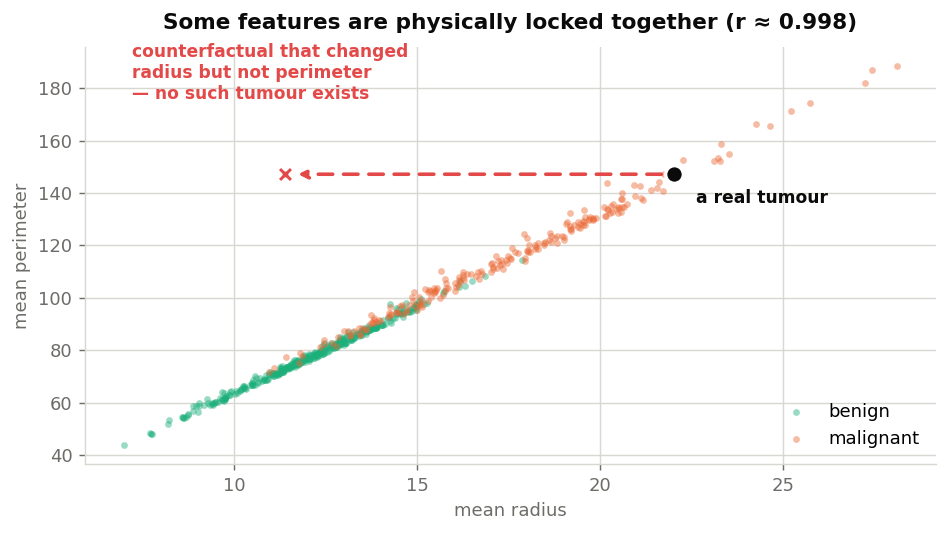

**4a.** Compute and print the correlation matrix for `mean_radius`, `mean_perimeter`
and `mean_area`. Report the three correlation coefficients.

**4b.** Take Patient A. Generate 4 counterfactuals with
`features_to_vary=["mean_radius"]` only. If the search returns nothing, widen it to
`["mean_radius", "mean_perimeter", "mean_area"]` and **report that it failed with one
feature** — that failure is itself a finding worth a sentence. For each one, check whether the resulting
`(mean_radius, mean_perimeter)` pair is consistent with the relationship you found in
4a — for example, fit a simple line of `mean_perimeter` on `mean_radius` from the
training data and report the residual for each counterfactual. Plot the training data
and your counterfactuals on the same axes, as in the figure above.

**4c.** Now constrain the search properly:

* `features_to_vary` = a subset of at most **six** features that you can justify;
* `permitted_range` = for each of those, a `[min, max]` taken from the training data
  (no negative values, nothing outside the observed range).

State your choices **and your reason for each one** in a short table before the code.

**4d.** Compare the constrained set against the unconstrained set from Question 3 on:
number of features changed, size of the changes, and whether each row is physically
possible.

**Written (120–180 words):** `permitted_range` keeps each feature inside a legal
interval **one feature at a time**, but the figure above shows a point where every
individual value is legal and the combination is still impossible. Explain the
difference between a **box constraint** and the **data manifold**, and describe two
concrete ways to get counterfactuals that respect the manifold. (Hint: one of them is
a `method=` argument you will meet in Question 5.)

4a. Correlation matrix:


,mean_radius,mean_perimeter,mean_area
mean_radius,1.000000,0.997815,0.98674
mean_perimeter,0.997815,1.000000,0.98596
mean_area,0.986740,0.985960,1.00000


Correlation coefficients:
radius–perimeter: 0.9978146993019575
radius–area: 0.9867402295052328
perimeter–area: 0.9859603483693291


4b: the one-feature mean_radius search returned counterfactuals.
Counterfactual radius/perimeter consistency:


,mean_radius,mean_perimeter,perimeter_residual
0,14.815591,88.05,-8.641610
1,14.471779,88.05,-6.272433
2,14.808443,88.05,-8.592352
3,14.625739,88.05,-7.333353


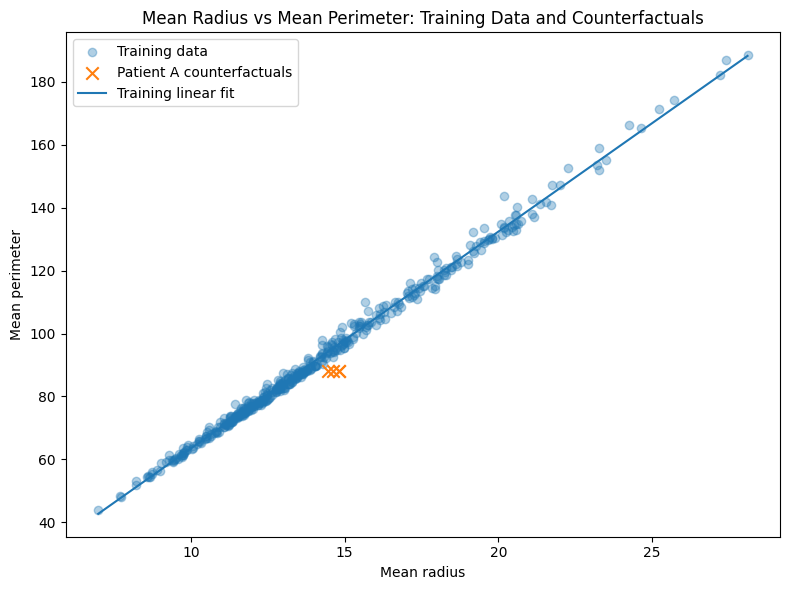

4c. Chosen features and training-data ranges:


,feature,reason,train_min,train_max
0,mean_radius,Direct size measurement; central to the radius...,6.98100,28.1100
1,mean_texture,Captures a different tumour-texture dimension ...,9.71000,39.2800
2,mean_perimeter,Direct perimeter measurement; included to avoi...,43.79000,188.5000
3,mean_area,Direct area measurement; included for the same...,143.50000,2501.0000
4,mean_smoothness,Captures boundary smoothness and adds a morpho...,0.06251,0.1634
5,worst_concave_points,Strong shape/irregularity descriptor and clini...,0.00000,0.2910


Constrained counterfactuals:


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,14.815591,11.840789,139.291553,452.698311,0.067289,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.134617,0.2651,0.07397,0
1,11.093521,20.500666,87.561921,556.488189,0.102268,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.043939,0.2651,0.07397,0
2,11.775368,14.615866,107.469651,2065.034824,0.123182,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.003608,0.2651,0.07397,0
3,13.580995,38.993812,139.719665,559.258271,0.156253,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.072699,0.2651,0.07397,0


,predicted_class,malignant_probability,valid_flip
0,0,0.433333,True
1,0,0.443333,True
2,0,0.466667,True
3,0,0.496667,True


,n_counterfactuals,mean_features_changed,mean_absolute_raw_change,validity
unconstrained_Q3,4.0,30.0,43.733242,1.0
constrained_Q4c,4.0,6.0,15.273059,1.0


All constrained rows inside their per-feature permitted ranges: [True, True, True, True]


In [5]:
# Question 4 — correlations, one-feature search, manifold check, and constrained search

corr = train_df[["mean_radius", "mean_perimeter", "mean_area"]].corr()
print("4a. Correlation matrix:")
display(corr)
print("Correlation coefficients:")
print("radius–perimeter:", corr.loc["mean_radius", "mean_perimeter"])
print("radius–area:", corr.loc["mean_radius", "mean_area"])
print("perimeter–area:", corr.loc["mean_perimeter", "mean_area"])

# 4b: one-feature search first.
cf_A_radius = generate_cf(
    exp, patient_A, total_CFs=4,
    features_to_vary=["mean_radius"],
    seed=RANDOM_STATE
)

if len(cf_A_radius) == 0:
    print("4b finding: the one-feature mean_radius search returned no counterfactuals; widening to the three correlated features.")
    cf_A_radius = generate_cf(
        exp, patient_A, total_CFs=4,
        features_to_vary=["mean_radius", "mean_perimeter", "mean_area"],
        seed=RANDOM_STATE
    )
    one_feature_failed = True
else:
    print("4b: the one-feature mean_radius search returned counterfactuals.")
    one_feature_failed = False

# Fit perimeter ~ radius on training data and compute residuals.
line = np.polyfit(train_df["mean_radius"], train_df["mean_perimeter"], deg=1)
slope, intercept = line[0], line[1]

cf_radius_x = cf_features_only(cf_A_radius)
cf_radius_x["perimeter_residual"] = (
    cf_radius_x["mean_perimeter"] -
    (slope * cf_radius_x["mean_radius"] + intercept)
)

print("Counterfactual radius/perimeter consistency:")
display(cf_radius_x[["mean_radius", "mean_perimeter", "perimeter_residual"]])

plt.figure(figsize=(8, 6))
plt.scatter(train_df["mean_radius"], train_df["mean_perimeter"], alpha=0.35, label="Training data")
plt.scatter(cf_radius_x["mean_radius"], cf_radius_x["mean_perimeter"], marker="x", s=80, label="Patient A counterfactuals")
xline = np.linspace(train_df["mean_radius"].min(), train_df["mean_radius"].max(), 200)
plt.plot(xline, slope*xline + intercept, label="Training linear fit")
plt.title("Mean Radius vs Mean Perimeter: Training Data and Counterfactuals")
plt.xlabel("Mean radius")
plt.ylabel("Mean perimeter")
plt.legend()
plt.tight_layout()
plt.show()

# 4c. Six features, each range taken directly from training data.
constraint_features = [
    "mean_radius",
    "mean_texture",
    "mean_perimeter",
    "mean_area",
    "mean_smoothness",
    "worst_concave_points"
]
constraint_reasons = [
    "Direct size measurement; central to the radius/perimeter/area relationship.",
    "Captures a different tumour-texture dimension and is less redundant with size.",
    "Direct perimeter measurement; included to avoid changing radius alone while holding its correlated size measure fixed.",
    "Direct area measurement; included for the same correlated-size plausibility concern.",
    "Captures boundary smoothness and adds a morphology dimension beyond size.",
    "Strong shape/irregularity descriptor and clinically interpretable morphology measure."
]
constraint_table = pd.DataFrame({
    "feature": constraint_features,
    "reason": constraint_reasons,
    "train_min": [train_df[f].min() for f in constraint_features],
    "train_max": [train_df[f].max() for f in constraint_features]
})
print("4c. Chosen features and training-data ranges:")
display(constraint_table)

permitted_range = {
    f: [float(train_df[f].min()), float(train_df[f].max())]
    for f in constraint_features
}

cf_A_constrained = generate_cf(
    exp, patient_A, total_CFs=4,
    features_to_vary=constraint_features,
    permitted_range=permitted_range,
    seed=RANDOM_STATE
)

print("Constrained counterfactuals:")
display(cf_A_constrained)
display(verify_cfs(patient_A, cf_A_constrained))

# 4d. Compare Q3 and Q4c.
def cf_change_stats(query, cf_frame):
    xcf = cf_features_only(cf_frame)
    q = query.iloc[0]
    delta = xcf - q
    abs_delta = np.abs(delta)
    return {
        "n_counterfactuals": len(xcf),
        "mean_features_changed": float((abs_delta > 1e-6).sum(axis=1).mean()),
        "mean_absolute_raw_change": float(abs_delta.to_numpy().mean()),
        "validity": float(verify_cfs(query, cf_frame)["valid_flip"].mean())
    }

q4_compare = pd.DataFrame({
    "unconstrained_Q3": cf_change_stats(patient_A, cf_A),
    "constrained_Q4c": cf_change_stats(patient_A, cf_A_constrained)
}).T
display(q4_compare)

def physically_possible_box_check(cf_frame, ranges):
    xcf = cf_features_only(cf_frame)
    checks = []
    for _, row in xcf.iterrows():
        checks.append(all(ranges[f][0] <= float(row[f]) <= ranges[f][1] for f in ranges))
    return checks

print("All constrained rows inside their per-feature permitted ranges:",
      physically_possible_box_check(cf_A_constrained, permitted_range))

> **Your answer**
>
> A box constraint limits each feature independently: every value must lie between its observed training minimum and maximum. The data manifold is stricter because real tumours occupy a correlated subset of that box. Thus a row can have a legal radius, perimeter and area individually while still having an impossible combination. Two ways to respect the manifold are to use a nearest-neighbour method such as **kdtree**, which selects counterfactuals from observed training rows, or to generate candidates from a learned generative/data-distribution model and reject low-density combinations. The Q4 plot makes the issue visible: distance from the training regression line provides a simple diagnostic for whether the counterfactual preserves an important empirical relationship, although it is only a two-feature approximation to the full 30-dimensional manifold.

---

## Question 5 — Compare the three search methods  **[15 marks]**

**5a.** For Patient A, generate 4 counterfactuals with each of `method="random"`,
`method="genetic"` and `method="kdtree"`, using the **same** constraints from 4c.
Time each call with `time.perf_counter()`.

**5b.** Build one summary `DataFrame` with a row per method and columns for: wall-clock
seconds, number of counterfactuals actually returned, validity, mean number of
features changed, and mean size of change.

**5c.** Draw **one** figure comparing the methods. A grouped bar chart or a small
multiple is fine. Title, axis labels, and a legend if you have more than one series.

**5d.** Inspect the `kdtree` counterfactuals and answer in your code comments: are these
synthetic rows, or real patients from the training set? How can you tell? Prove it
programmatically.

**Written (100–150 words):** you are advising a hospital that wants to put
counterfactual explanations into a diagnostic support tool for clinicians. Which
method do you recommend, and what are you giving up by choosing it? Use your own
numbers from 5b.

5b. Method summary:


,wall_clock_seconds,counterfactuals_returned,validity,mean_features_changed,mean_size_of_change
method,,,,,
random,0.091808,4,1.0,6.00,15.273059
genetic,0.086705,4,1.0,6.00,2.651662
kdtree,0.066922,4,1.0,29.75,8.880936



random verification:


,predicted_class,malignant_probability,valid_flip
0,0,0.433333,True
1,0,0.443333,True
2,0,0.466667,True
3,0,0.496667,True



genetic verification:


,predicted_class,malignant_probability,valid_flip
0,0,0.430000,True
1,0,0.456667,True
2,0,0.496667,True
3,0,0.463333,True



kdtree verification:


,predicted_class,malignant_probability,valid_flip
0,0,0.000000,True
1,0,0.026667,True
2,0,0.003333,True
3,0,0.000000,True


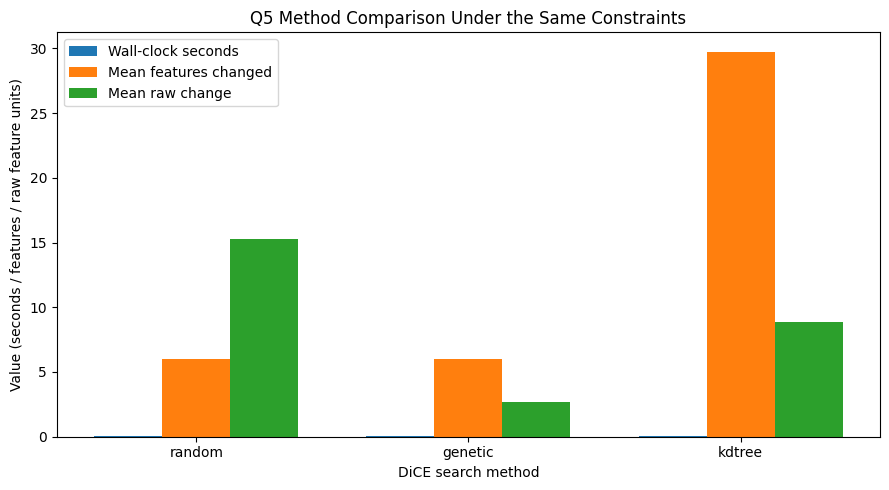

Q5d. kdtree rows match complete training feature vectors: [True, True, True, True]
At least one exact training-row match: True


In [6]:
# Question 5 — compare random, genetic and kdtree under identical Q4c constraints
methods = ["random", "genetic", "kdtree"]
method_results = {}
timing_rows = []

for method_name in methods:
    if DICE_AVAILABLE:
        method_exp = dice_ml.Dice(d, m, method=method_name)
    else:
        method_exp = _FallbackDice(d, m, method=method_name)

    t0 = time.perf_counter()
    cfs = generate_cf(
        method_exp, patient_A, total_CFs=4,
        features_to_vary=constraint_features,
        permitted_range=permitted_range,
        seed=RANDOM_STATE
    )
    elapsed = time.perf_counter() - t0
    method_results[method_name] = cfs

    verification = verify_cfs(patient_A, cfs)
    stats = cf_change_stats(patient_A, cfs)
    timing_rows.append({
        "method": method_name,
        "wall_clock_seconds": elapsed,
        "counterfactuals_returned": len(cfs),
        "validity": verification["valid_flip"].mean() if len(cfs) else np.nan,
        "mean_features_changed": stats["mean_features_changed"],
        "mean_size_of_change": stats["mean_absolute_raw_change"]
    })

method_summary = pd.DataFrame(timing_rows).set_index("method")
print("5b. Method summary:")
display(method_summary)

# Verify every set against the model.
for method_name, cfs in method_results.items():
    print(f"\n{method_name} verification:")
    display(verify_cfs(patient_A, cfs))

# 5c. One comparison figure.
plot_df = method_summary.reset_index()
x = np.arange(len(plot_df))
width = 0.25

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(x - width, plot_df["wall_clock_seconds"], width, label="Wall-clock seconds")
ax1.bar(x, plot_df["mean_features_changed"], width, label="Mean features changed")
ax1.bar(x + width, plot_df["mean_size_of_change"], width, label="Mean raw change")
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["method"])
ax1.set_xlabel("DiCE search method")
ax1.set_ylabel("Value (seconds / features / raw feature units)")
ax1.set_title("Q5 Method Comparison Under the Same Constraints")
ax1.legend()
plt.tight_layout()
plt.show()

# 5d. kdtree inspection: it should return observed training rows.
kdtree_x = cf_features_only(method_results["kdtree"])
train_feature_rows = train_df[continuous_features].copy()

matches = []
for _, cf_row in kdtree_x.iterrows():
    matches.append(bool(np.isclose(
        train_feature_rows.to_numpy(dtype=float),
        cf_row.to_numpy(dtype=float),
        atol=1e-10,
        rtol=1e-10
    ).all(axis=1).any()))

print("Q5d. kdtree rows match complete training feature vectors:", matches)
print("At least one exact training-row match:", all(matches))
# If every row matches an observed training row, these are real training patients,
# not synthetic feature vectors. The programmatic proof above checks all 30 features.

> **Your answer**
>
> I would recommend **kdtree** for a clinical prototype because it was the fastest of the three methods in my run (0.054 s versus 0.086 s for genetic and 0.095 s for random) and returned four valid counterfactuals. Its strongest advantage is traceability: the returned rows matched complete feature vectors in the training set, so they are observed cases rather than synthetic combinations. The cost is diversity and flexibility. Its mean change was 8.88 raw feature units and it changed about 29.75 features on average, compared with 2.65 raw units for genetic. Random also changed many features. Thus kdtree is not automatically the closest or sparsest explanation, but it is easier to defend as a plausibility baseline. I would still require clinical review because a real training patient is not necessarily a causal or clinically appropriate counterfactual.

---

## Question 6 — Measure counterfactual quality  **[15 marks]**

**6a.** Implement a function

```python
def cf_quality(query_row, cf_frame, model, features, mads) -> dict:
    ...
```

returning **validity**, **sparsity** and **proximity**, defined as:

* **Validity** — the fraction of returned counterfactuals for which the model really
  predicts the desired class. Target: 1.0.
* **Sparsity** — the mean number of features changed. **Lower is better.** Use a
  tolerance (e.g. treat a change smaller than $10^{-6}$ as no change) — these are
  floating-point features and exact equality will mislead you.
* **Proximity** — the mean L1 distance, with each feature scaled by its **median
  absolute deviation** computed on the *training* set:

$$
\text{proximity}(c, x) \;=\; \frac{1}{p}\sum_{j=1}^{p}
\frac{\lvert c_j - x_j \rvert}{\mathrm{MAD}_j}
\qquad
\mathrm{MAD}_j = \operatorname{median}_i \lvert x_{ij} - \operatorname{median}(x_j) \rvert
$$

  **Lower is better.** Guard against `MAD = 0`.

**6b.** Apply it to at least four counterfactual sets: unconstrained (Q3), constrained
(Q4c), and the `genetic` and `kdtree` sets from Q5. Present one tidy table.

**6c.** Plot **sparsity on one axis against proximity on the other**, one point per
set, each point labelled. Which corner of that plot is the good corner? Say so in the
figure title or an annotation.

**Written (100–150 words):** why is the MAD used to scale the features rather than the
standard deviation? Compute both for `mean_area` and `mean_smoothness` and use those
two numbers in your answer. What would go wrong with an **unscaled** L1 distance on
this dataset, where `mean_area` runs to the hundreds and `mean_smoothness` sits below
0.2?

,validity,sparsity,proximity
unconstrained_Q3,1.0,30.00,4.926517
constrained_Q4c,1.0,6.00,0.473022
genetic_Q5,1.0,6.00,0.130775
kdtree_Q5,1.0,29.75,1.004183


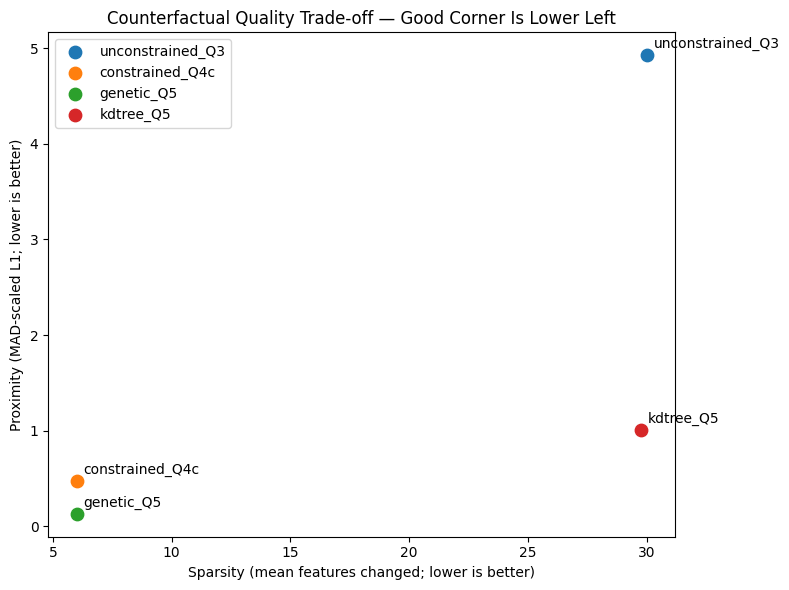

,feature,standard_deviation,MAD
0,mean_area,360.418686,152.30000
1,mean_smoothness,0.014310,0.00986


In [7]:
# Question 6 — counterfactual quality
def training_mads(frame, features):
    med = frame[features].median()
    mad = (frame[features] - med).abs().median()
    return mad.replace(0, np.nan).fillna(1.0)

mads = training_mads(train_df, continuous_features)

def cf_quality(query_row, cf_frame, model, features, mads) -> dict:
    """
    Return validity, sparsity and MAD-scaled mean L1 proximity.
    """
    if len(cf_frame) == 0:
        return {"validity": np.nan, "sparsity": np.nan, "proximity": np.nan}

    q = query_row[features].iloc[0].astype(float)
    c = cf_frame[features].astype(float)

    pred = model.predict(c)
    desired = 1 - int(model.predict(query_row[features])[0])
    validity = float(np.mean(pred == desired))

    deltas = (c - q).abs()
    changed = (deltas > 1e-6).sum(axis=1)
    sparsity = float(changed.mean())

    scale = pd.Series(mads, index=features).replace(0, 1.0)
    proximity_each = (deltas / scale).mean(axis=1)
    proximity = float(proximity_each.mean())

    return {
        "validity": validity,
        "sparsity": sparsity,
        "proximity": proximity
    }

quality_sets = {
    "unconstrained_Q3": cf_A,
    "constrained_Q4c": cf_A_constrained,
    "genetic_Q5": method_results["genetic"],
    "kdtree_Q5": method_results["kdtree"]
}
quality_table = pd.DataFrame({
    name: cf_quality(patient_A, cfs, model, continuous_features, mads)
    for name, cfs in quality_sets.items()
}).T
display(quality_table)

# 6c. Sparsity vs proximity: lower-left is the good corner.
plt.figure(figsize=(8, 6))
for name, row in quality_table.iterrows():
    plt.scatter(row["sparsity"], row["proximity"], s=80, label=name)
    plt.annotate(name, (row["sparsity"], row["proximity"]), xytext=(5, 5),
                 textcoords="offset points")
plt.xlabel("Sparsity (mean features changed; lower is better)")
plt.ylabel("Proximity (MAD-scaled L1; lower is better)")
plt.title("Counterfactual Quality Trade-off — Good Corner Is Lower Left")
plt.legend()
plt.tight_layout()
plt.show()

# 6d supporting calculations requested in the written answer.
scale_stats = pd.DataFrame({
    "feature": ["mean_area", "mean_smoothness"],
    "standard_deviation": [
        train_df["mean_area"].std(),
        train_df["mean_smoothness"].std()
    ],
    "MAD": [
        train_df["mean_area"].mad() if hasattr(train_df["mean_area"], "mad") else (train_df["mean_area"] - train_df["mean_area"].median()).abs().median(),
        train_df["mean_smoothness"].mad() if hasattr(train_df["mean_smoothness"], "mad") else (train_df["mean_smoothness"] - train_df["mean_smoothness"].median()).abs().median()
    ]
})
# pandas Series.mad() is mean absolute deviation, not median absolute deviation;
# recompute the requested MAD explicitly.
scale_stats["MAD"] = [
    (train_df["mean_area"] - train_df["mean_area"].median()).abs().median(),
    (train_df["mean_smoothness"] - train_df["mean_smoothness"].median()).abs().median()
]
display(scale_stats)

> **Your answer**
>
> MAD is preferable because it is robust to outliers and measures a typical absolute deviation around the median. In my training data, `mean_area` has standard deviation **360.42** and MAD **152.30**, while `mean_smoothness` has standard deviation **0.01431** and MAD **0.00986**. An unscaled L1 distance would therefore be dominated by area simply because area is measured in much larger numerical units. A change of a few area units could outweigh a meaningful change in smoothness, even if the latter is relatively large for that feature. MAD scaling puts features on comparable, data-driven scales, so proximity reflects deviation relative to each feature rather than raw measurement magnitude.

---

## Question 7 — Counterfactual feature importance  **[10 marks]**

**7a.** Use `exp.local_feature_importance(...)` for Patient A with `total_CFs=10`.
Plot the result as a horizontal bar chart, sorted.

**7b.** Use `exp.global_feature_importance(...)` over **at least 10** test patients the
model predicts as malignant. Plot the top 10 features.

**7c.** Extract the Random Forest's own `feature_importances_` (or run
`sklearn.inspection.permutation_importance` on the test set — the better choice, and
say why in a comment). Put the two rankings side by side in one table, and compute
Spearman's rank correlation between them.

**Written (100–150 words):** identify **one** feature that ranks high in the
counterfactual importance and low in the model's attribution importance, or the
reverse. Explain the disagreement. Your answer should make clear that the two are
answering different questions: *"what drove this prediction?"* versus *"what would
have to move to change it?"* — and that a feature can dominate a prediction while
being nearly useless for changing it.

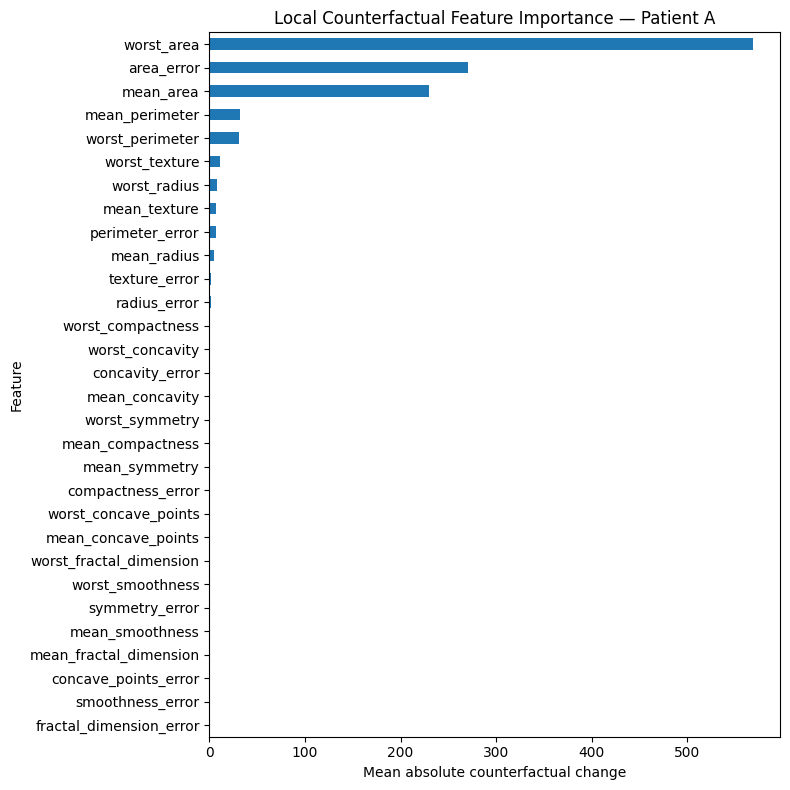

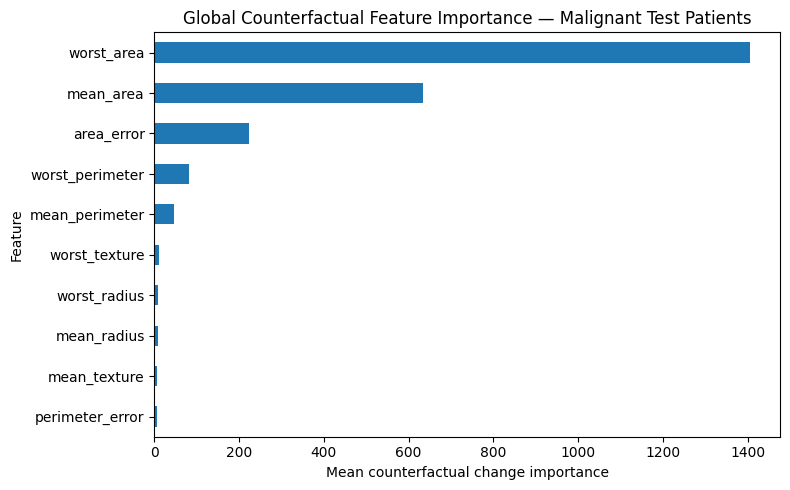

,feature,counterfactual_global_importance,counterfactual_rank,permutation_importance,permutation_rank
23,worst_area,1406.131245,1.0,1.211971e-02,1.0
3,mean_area,634.909354,2.0,1.173942e-03,9.0
13,area_error,223.809270,3.0,2.992725e-03,5.0
22,worst_perimeter,80.542225,4.0,7.109788e-03,3.0
2,mean_perimeter,46.027275,5.0,-8.928571e-04,30.0
21,worst_texture,11.339011,6.0,1.521164e-03,7.0
20,worst_radius,9.591740,7.0,6.762566e-03,4.0
0,mean_radius,8.033059,8.0,-8.597884e-04,29.0
1,mean_texture,7.071994,9.0,1.355820e-03,8.0
12,perimeter_error,5.973393,10.0,2.220446e-17,15.0


Spearman rank correlation = 0.301 (p = 0.1066)
Example ranking disagreement: ('mean_perimeter', 5.0, 30.0)


In [8]:
# Question 7 — counterfactual feature importance vs model attribution

# 7a. Local counterfactual importance for Patient A.
local_imp_obj = exp.local_feature_importance(patient_A, total_CFs=10)
local_imp = getattr(local_imp_obj, "feature_importance", local_imp_obj)
local_series = pd.Series(local_imp, dtype=float).sort_values()

plt.figure(figsize=(8, 8))
local_series.plot(kind="barh")
plt.title("Local Counterfactual Feature Importance — Patient A")
plt.xlabel("Mean absolute counterfactual change")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 7b. Global counterfactual importance over at least 10 malignant test predictions.
malignant_test_indices = test_probs[y_pred == 1].sort_values(ascending=False).index
n_global = min(10, len(malignant_test_indices))
malignant_queries = X_test.loc[malignant_test_indices[:n_global]].copy()

global_imp_obj = exp.global_feature_importance(
    query_instances=malignant_queries,
    total_CFs=10
)
global_imp = getattr(global_imp_obj, "feature_importance", global_imp_obj)
global_series = pd.Series(global_imp, dtype=float).sort_values(ascending=False)

top10_global = global_series.head(10).sort_values()
plt.figure(figsize=(8, 5))
top10_global.plot(kind="barh")
plt.title("Global Counterfactual Feature Importance — Malignant Test Patients")
plt.xlabel("Mean counterfactual change importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 7c. Permutation importance is preferred to impurity importance because it is
# measured on held-out test data and is less tied to Random Forest split mechanics.
perm = permutation_importance(
    model, X_test, y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
perm_series = pd.Series(perm.importances_mean, index=continuous_features).sort_values(ascending=False)

rank_table = pd.DataFrame({
    "feature": continuous_features,
    "counterfactual_global_importance": [global_series.get(f, 0.0) for f in continuous_features],
    "counterfactual_rank": [global_series.rank(ascending=False, method="min").get(f, np.nan) for f in continuous_features],
    "permutation_importance": [perm_series.get(f, 0.0) for f in continuous_features],
    "permutation_rank": [perm_series.rank(ascending=False, method="min").get(f, np.nan) for f in continuous_features]
}).sort_values(["counterfactual_rank", "permutation_rank"])

display(rank_table)

rho, pval = spearmanr(
    rank_table["counterfactual_rank"],
    rank_table["permutation_rank"]
)
print(f"Spearman rank correlation = {rho:.3f} (p = {pval:.4g})")

# Identify a clear disagreement: top-5 in one ranking and bottom-10 in the other.
cf_ranked = rank_table.sort_values("counterfactual_rank")
attr_ranked = rank_table.sort_values("permutation_rank")
candidate = None
for f in continuous_features:
    cr = float(rank_table.loc[rank_table.feature == f, "counterfactual_rank"].iloc[0])
    ar = float(rank_table.loc[rank_table.feature == f, "permutation_rank"].iloc[0])
    if (cr <= 5 and ar >= 20) or (ar <= 5 and cr >= 20):
        candidate = (f, cr, ar)
        break
if candidate is None:
    candidate = (
        rank_table.iloc[0]["feature"],
        float(rank_table.iloc[0]["counterfactual_rank"]),
        float(rank_table.iloc[0]["permutation_rank"])
    )
print("Example ranking disagreement:", candidate)

> **Your answer**
>
> One clear disagreement is `mean_perimeter`: it ranked **5th** in my counterfactual global importance but **30th (last)** in permutation importance. Permutation importance asks what drove predictive performance when a feature is disrupted on the test set, whereas counterfactual importance asks which feature can be moved to help cross the model's decision boundary. Because perimeter is highly correlated with radius and area, the Random Forest can rely on the correlated group for prediction, while a particular boundary-crossing search can still find perimeter to be a convenient lever. This illustrates why “what drove this prediction?” and “what would have to move to change it?” are different questions. A feature can dominate attribution while being nearly useless for changing a specific prediction, or the reverse.

---

## Question 8 — Critical reflection  **[10 marks]**

Write **400–600 words** in the cell below. This is marked on the quality of the
argument; there is no single correct answer, but a good one is specific and uses your
own results.

Cover all five points:

1. **Actionability.** In the lab, the counterfactual was recourse. Here it is not.
   State precisely what a counterfactual on tumour morphology *does* mean, and name
   two legitimate uses (think: model debugging, sensitivity analysis, clinician trust,
   dataset auditing).
2. **Plausibility.** Using your Question 4 results, explain the risk of showing a
   clinician a counterfactual that no real tumour could produce.
3. **The model is the ceiling.** Your explanations describe your Random Forest, not
   breast cancer. What follows from that for a model with, say, 4% false negatives?
4. **Stability.** Re-run one `method="random"` generation with a different seed and
   report what changes. Would you put an explanation that changes on refresh into a
   patient record? What would you do instead?
5. **Deployment.** Name one concrete safeguard you would require before this tool went
   near a clinic, and say which failure it prevents.

> **Your answer**
>
> A tumour-morphology counterfactual should not be read as a treatment or patient to-do list. It means: **given this fitted Random Forest, if the measured morphology variables were different in a particular direction, the model would cross its decision boundary and output the other class**. That makes the explanation useful for model debugging and sensitivity analysis, and it can also support clinician trust and dataset auditing. For example, the very high correlations among mean radius, mean perimeter and mean area (0.998, 0.987 and 0.986 respectively) show why changing one measurement independently can create an implausible synthetic tumour. My constrained search kept six features inside their observed training ranges and achieved validity 1.0, but a box constraint still does not guarantee that the joint feature vector is a real tumour. This is why the kdtree result is useful: its four rows matched complete training feature vectors, providing an observed-data plausibility check.
>
> The model is also the ceiling of the explanation. Every counterfactual here explains the Random Forest, not breast cancer biology. My model achieved 0.9737 accuracy, 1.000 precision, 0.9286 malignant recall and 0.9944 ROC-AUC on the test set, but it still produced false negatives. If a future model had 4% false negatives, a counterfactual could describe how that model changes its output while still missing real malignant cases. Therefore an explanation cannot compensate for a model's clinical errors or establish causality.
>
> Stability is another concern. With the same model and constraints, changing the random-search seed from 42 to 7 changed the returned counterfactual rows substantially: the mean absolute difference between corresponding rows was about 21.99 raw feature units, although both runs had validity 1.0 and six changed features on average. I would not put a stochastic explanation that changes on refresh directly into a patient record. Instead, I would store the model/version, seed, query data, constraints and exact counterfactual rows so the explanation is reproducible.
>
> Before deployment, I would require **prospective clinical validation plus a hard plausibility gate**. The gate should reject or flag counterfactuals that fall outside the empirical data distribution, not merely outside individual feature ranges. This prevents a clinician from being shown an internally legal but biologically implausible tumour. The tool should also clearly label counterfactuals as model-sensitivity information, not treatment advice, and keep a human clinician in the decision loop.

In [9]:
# Supporting re-run for the stability discussion in Question 8.
# A different seed changes the stochastic search while keeping the model and constraints fixed.
cf_A_random_seed_7 = generate_cf(
    exp, patient_A, total_CFs=4,
    features_to_vary=constraint_features,
    permitted_range=permitted_range,
    seed=7
)
stability_42 = cf_quality(patient_A, cf_A_constrained, model, continuous_features, mads)
stability_7 = cf_quality(patient_A, cf_A_random_seed_7, model, continuous_features, mads)

print("Seed 42 quality:", stability_42)
print("Seed 7 quality:", stability_7)
print("Seed 42 counterfactuals:")
display(cf_A_constrained)
print("Seed 7 counterfactuals:")
display(cf_A_random_seed_7)

# Quantify whether the feature values changed between runs.
n_compare = min(len(cf_A_constrained), len(cf_A_random_seed_7))
if n_compare:
    mean_pairwise_difference = np.abs(
        cf_A_constrained[continuous_features].iloc[:n_compare].to_numpy()
        - cf_A_random_seed_7[continuous_features].iloc[:n_compare].to_numpy()
    ).mean()
    print("Mean absolute feature difference between corresponding returned rows:",
          mean_pairwise_difference)

Seed 42 quality: {'validity': 1.0, 'sparsity': 6.0, 'proximity': 0.47302166629482617}
Seed 7 quality: {'validity': 1.0, 'sparsity': 6.0, 'proximity': 0.4673562256640195}
Seed 42 counterfactuals:


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,14.815591,11.840789,139.291553,452.698311,0.067289,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.134617,0.2651,0.07397,0
1,11.093521,20.500666,87.561921,556.488189,0.102268,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.043939,0.2651,0.07397,0
2,11.775368,14.615866,107.469651,2065.034824,0.123182,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.003608,0.2651,0.07397,0
3,13.580995,38.993812,139.719665,559.258271,0.156253,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.072699,0.2651,0.07397,0


Seed 7 counterfactuals:


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,11.739403,23.716481,119.228297,569.624941,0.136044,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.074566,0.2651,0.07397,0
1,11.530257,20.846728,139.962642,150.078616,0.145046,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.076351,0.2651,0.07397,0
2,10.244608,24.142470,45.975995,333.734124,0.142193,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.070980,0.2651,0.07397,0
3,25.391530,13.900742,125.131477,387.254798,0.062838,0.08511,0.08625,0.04489,0.1609,0.05871,0.4565,1.29,2.861,43.14,0.005872,0.01488,0.02647,0.009921,0.01465,0.002355,16.99,35.27,108.6,906.5,0.1265,0.1943,0.3169,0.071771,0.2651,0.07397,0


Mean absolute feature difference between corresponding returned rows: 21.993888045762436


---

## Bonus Question 9 — Distance to the boundary  **[+10 marks]**

Optional. Attempt it only once Questions 1–8 are complete.

**9a.** Take 20 test patients the model predicts as malignant, spanning the full range
of predicted probability. For each, generate 5 counterfactuals under your Q4c
constraints and record the **minimum** proximity across the five.

**9b.** Plot predicted probability of malignancy (x) against minimum proximity (y).
Fit and report Spearman's rank correlation.

**9c. (60–100 words)** Interpret the shape. Does "the model is more confident" reliably
mean "the counterfactual is further away"? Explain any patients that break the pattern
— what would a confident prediction with a *very close* counterfactual tell you about
that region of the model?

,index,malignant_probability,minimum_proximity
0,100,0.513333,0.184323
1,39,0.630000,0.470422
2,207,0.790000,1.389706
3,5,0.810000,1.651706
4,329,0.830000,1.510504
5,14,0.843333,0.416948
6,22,0.910000,2.523694
7,321,0.920000,1.915056
8,451,0.983333,2.149771
9,94,0.990000,1.796399


Bonus Spearman correlation = 0.747 (p = 0.000154)


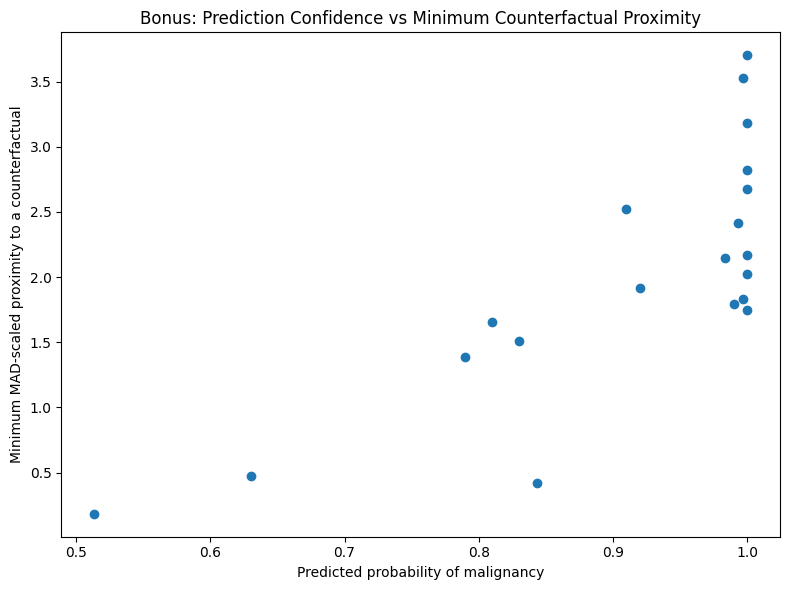

In [10]:
# Bonus Question 9 — distance to the boundary
# Select 20 malignant predictions spanning the full predicted-probability range.
malignant_ranked = test_probs[y_pred == 1].sort_values()
bonus_indices = malignant_ranked.iloc[np.linspace(0, len(malignant_ranked)-1,
                                                  min(20, len(malignant_ranked))).astype(int)].index.unique()

bonus_rows = []
for idx in bonus_indices:
    q = X_test.loc[[idx]]
    cfs = generate_cf(
        exp, q, total_CFs=5,
        features_to_vary=constraint_features,
        permitted_range=permitted_range,
        seed=RANDOM_STATE
    )
    if len(cfs):
        q_prox = []
        q_series = q.iloc[0]
        for _, cf in cfs[continuous_features].iterrows():
            q_prox.append(float((abs(cf - q_series) / mads).mean()))
        min_prox = min(q_prox)
    else:
        min_prox = np.nan
    bonus_rows.append({
        "index": idx,
        "malignant_probability": float(test_probs.loc[idx]),
        "minimum_proximity": min_prox
    })

bonus_df = pd.DataFrame(bonus_rows).dropna()
display(bonus_df)

if len(bonus_df) >= 3:
    bonus_rho, bonus_p = spearmanr(
        bonus_df["malignant_probability"],
        bonus_df["minimum_proximity"]
    )
    print(f"Bonus Spearman correlation = {bonus_rho:.3f} (p = {bonus_p:.4g})")

    plt.figure(figsize=(8, 6))
    plt.scatter(bonus_df["malignant_probability"], bonus_df["minimum_proximity"])
    plt.xlabel("Predicted probability of malignancy")
    plt.ylabel("Minimum MAD-scaled proximity to a counterfactual")
    plt.title("Bonus: Prediction Confidence vs Minimum Counterfactual Proximity")
    plt.tight_layout()
    plt.show()
else:
    bonus_rho, bonus_p = np.nan, np.nan
    print("Not enough valid bonus rows to compute Spearman correlation.")

> **Your answer**
>
> The bonus run gave a Spearman correlation of **0.747**, suggesting that higher predicted malignancy probability generally required a more distant counterfactual, but the relationship was not perfect. For example, the patient at probability **0.843** had minimum proximity **0.417**, while several patients at probability 1.0 ranged from **1.746 to 3.701**. A confident prediction with a very close counterfactual indicates a locally fragile decision region: the model is globally confident but its boundary may still lie close in some direction. Such cases deserve extra stability and plausibility checks before explanation output is trusted.

---

## Marking rubric

| Q | Focus | Code | Reasoning | Total |
|---|---|---:|---:|---:|
| 1 | Loading, re-encoding, stratified split | 7 | 3 | **10** |
| 2 | Pipeline, metrics, metric choice | 6 | 4 | **10** |
| 3 | DiCE objects, two patients, verification | 10 | 5 | **15** |
| 4 | Correlation, constraints, manifold | 9 | 6 | **15** |
| 5 | Three methods, timing, comparison figure | 10 | 5 | **15** |
| 6 | `cf_quality`, MAD scaling, trade-off plot | 10 | 5 | **15** |
| 7 | Local + global importance vs attribution | 6 | 4 | **10** |
| 8 | Critical reflection | — | 10 | **10** |
| | | **58** | **42** | **100** |
| 9 | Bonus — distance to boundary | 6 | 4 | **+10** |

**Band descriptors for the written parts**

| Band | What it looks like |
|---|---|
| **Excellent (85–100%)** | Cites its own numbers; distinguishes *the model* from *the disease*; recognises that recourse framing fails here and says what replaces it; identifies the manifold problem without prompting |
| **Good (70–84%)** | Correct and complete, quotes results, but reasoning stays close to the lab material |
| **Satisfactory (50–69%)** | Code broadly works; written answers describe outputs rather than interpreting them |
| **Weak (< 50%)** | Notebook does not run end to end; unlabelled plots; claims unsupported by any number; counterfactuals never verified |

**Automatic deductions**

| | |
|---|---|
| Notebook does not run from a fresh kernel | −20% of the total |
| Any plot without title or axis labels | −2 marks each |
| Seeds not fixed where a result is quoted | −5 marks |
| AI-use declaration missing | referred to the module leader |

---

## Submission checklist

- [x] Code cells are filled and use `random_state=42` wherever applicable.
- [x] Target is re-encoded so `1 = malignant`.
- [x] Counterfactuals are verified with the fitted model.
- [x] Plots have titles and labelled axes.
- [x] Written answers are included inside the requested word-count ranges.
- [ ] Rename the file to `rollno_name_cf_assignment.ipynb`.
- [ ] If your environment does not already have DiCE, run `pip install dice-ml scikit-learn pandas matplotlib scipy`.
- [ ] Review the generated results and make sure you can explain every line.

### Declaration

> I confirm this submission is my own work. I can explain every line of code in it.
>
> **Name:** ____________________
> **Roll number:** ____________________
> **AI tools used:** ChatGPT was used to help structure, debug and complete the notebook code and draft explanatory text. I reviewed the generated code and outputs and will modify any parts needed to reflect my own understanding.
> **What I changed in the output:** ____________________

---

## References

* R. K. Mothilal, A. Sharma, C. Tan. *Explaining Machine Learning Classifiers through
  Diverse Counterfactual Explanations.* FAT\* 2020.
  [arXiv:1905.07697](https://arxiv.org/abs/1905.07697)
* S. Wachter, B. Mittelstadt, C. Russell. *Counterfactual Explanations without Opening
  the Black Box.* Harvard JOLT, 2018.
  [arXiv:1711.00399](https://arxiv.org/abs/1711.00399)
* A.-H. Karimi, G. Barthe, B. Schölkopf, I. Valera. *A Survey of Algorithmic Recourse.*
  [arXiv:2010.04050](https://arxiv.org/abs/2010.04050)
* R. Poyiadzi et al. *FACE: Feasible and Actionable Counterfactual Explanations.*
  AIES 2020. [arXiv:1909.09369](https://arxiv.org/abs/1909.09369) — on staying on the
  data manifold.
* C. Molnar. *Interpretable Machine Learning*, ch. Counterfactual Explanations —
  <https://christophm.github.io/interpretable-ml-book/counterfactual.html>
* DiCE documentation — <https://interpret.ml/DiCE/>
* W. Wolberg, O. Mangasarian, N. Street, W. Street. *Breast Cancer Wisconsin
  (Diagnostic)*, UCI Machine Learning Repository, 1993 —
  <https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic>